In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
#os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project")
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [5]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)


In [6]:
def create_sliding_window(data_df, string, window_days=7, forecast_horizon=1):
    """
    Outputs five DataFrames:
    - X_df: past window (arrays) + date
    - y_df: target next-day (arrays) + date
    - y_day_df: previous-day same-hour baseline + date
    - y_week_df: previous-week same-hour baseline + date
    - pct_df: percent change vs last window value + date
    """


    series = data_df[string].values
    dates = pd.to_datetime(data_df["Date"])

    hours_per_day = 24
    window_size = window_days * hours_per_day
    eps = 1e-9

    X, y = [], []
    y_day_before, y_week_before = [], []
    y_pct = []
    y_dates = []

    n = len(series)

    for i in range(0, n - window_size - forecast_horizon + 1):

        # Input window
        X_window = series[i : i + window_size]
        # Forecast target
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # Target date
        date_target = dates[i + window_size]

        # Previous-day baseline
        start_prev_day = i + window_size - hours_per_day
        if start_prev_day >= 0:
            prev_day = series[start_prev_day : start_prev_day + forecast_horizon]
        else:
            prev_day = np.full(forecast_horizon, np.nan)

        # Previous-week baseline
        start_prev_week = i + window_size - 7 * hours_per_day
        if start_prev_week >= 0:
            prev_week = series[start_prev_week : start_prev_week + forecast_horizon]
        else:
            prev_week = np.full(forecast_horizon, np.nan)

        # Percent change wrt last hour in window
        pct = (y_target - X_window[-1]) / (X_window[-1] + eps)

        # Append everything
        X.append(X_window.astype(np.float32))
        y.append(y_target.astype(np.float32))
        y_day_before.append(prev_day.astype(np.float32))
        y_week_before.append(prev_week.astype(np.float32))
        y_pct.append(pct.astype(np.float32))
        y_dates.append(date_target)

    # ---- Build DataFrames ----
    X_df = pd.DataFrame({"X": X, "Date": y_dates})
    y_df = pd.DataFrame({"y": y, "Date": y_dates})
    y_day_df = pd.DataFrame({"y_day": y_day_before, "Date": y_dates})
    y_week_df = pd.DataFrame({"y_week": y_week_before, "Date": y_dates})
    pct_df = pd.DataFrame({"pct": y_pct, "Date": y_dates})

    return X_df, y_df, y_day_df, y_week_df, pct_df


In [7]:
#Create sliding windows
X_df, y_df, y_day_df, y_week_df, y_per_df   = create_sliding_window(all_data,'EUR/MWh', window_days=7, forecast_horizon=1)

In [8]:
#Sanity check on the 168th hour
# print("-------------")
# print("Sanity check on the 168th hour")
# print("The input X is:", X_df["Values"].iloc[0])
# print("The target y is:", y_df["Values"].iloc[0])
# print("The previous day y_day_before is:", y_day_df["Values"].iloc[0])
# print("The previous week y_week_before is:", y_week_df["Values"].iloc[0])
# print("The percentage change y_per is:", y_per_df["Values"].iloc[0])

# print("-------------")
# print("True Values at 2019-10-08 00:00 (168th hour)")
# print("The true data past 168 inputs are:", all_data['EUR/MWh'].values[0:168])
# print("The true target is:", all_data['EUR/MWh'].values[168:169])
# print("The true previous day prediction is:", all_data['EUR/MWh'].values[144:145])
# print("The true previous week is:", all_data['EUR/MWh'].values[0:1])
# print("The true percentage change is:", (all_data['EUR/MWh'].values[168:169]-all_data['EUR/MWh'].values[167:168])/(all_data['EUR/MWh'].values[167:168]+1e-9))

print("-------------")
print("Sanity check on inputs:", 
      np.allclose(X_df["X"].iloc[0], all_data['EUR/MWh'].values[0:168]))

print("Sanity check on target:", 
      np.allclose(y_df["y"].iloc[0], all_data['EUR/MWh'].values[168:169]))

print("Sanity check on previous day:", 
      np.allclose(y_day_df["y_day"].iloc[0], all_data['EUR/MWh'].values[144:145]))

print("Sanity check on previous week:", 
      np.allclose(y_week_df["y_week"].iloc[0], all_data['EUR/MWh'].values[0:1]))

print("Sanity check on percentage change:", 
      np.allclose(y_per_df["pct"].iloc[0], (all_data['EUR/MWh'].values[168:169]-all_data['EUR/MWh'].values[167:168])/(all_data['EUR/MWh'].values[167:168]+1e-9)))

-------------
Sanity check on inputs: True
Sanity check on target: True
Sanity check on previous day: True
Sanity check on previous week: True
Sanity check on percentage change: True


In [11]:
df=pd.merge(X_df, y_df, on='Date')
df=pd.merge(df, y_day_df, on='Date')
df=pd.merge(df, y_week_df, on='Date')
df=pd.merge(df, y_per_df, on='Date')
df=df[['Date','X','y','y_day','y_week','pct']]
df

,Date,X,y,y_day,y_week,pct
0,2019-10-08 00:00:00,"[33.09, 27.72, 23.12, 16.46, 15.66, 21.39, 38....",[30.64],[28.99],[33.09],[-0.06499848]
1,2019-10-08 01:00:00,"[27.72, 23.12, 16.46, 15.66, 21.39, 38.51, 50....",[27.93],[27.07],[27.72],[-0.088446476]
2,2019-10-08 02:00:00,"[23.12, 16.46, 15.66, 21.39, 38.51, 50.03, 50....",[25.0],[27.0],[23.12],[-0.10490512]
3,2019-10-08 03:00:00,"[16.46, 15.66, 21.39, 38.51, 50.03, 50.97, 49....",[22.98],[25.77],[16.46],[-0.0808]
4,2019-10-08 04:00:00,"[15.66, 21.39, 38.51, 50.03, 50.97, 49.63, 46....",[20.71],[24.91],[15.66],[-0.09878155]
...,...,...,...,...,...,...
52064,2025-09-30 19:00:00,"[26.47, 58.0, 40.63, 18.63, 21.96, 21.02, 0.0,...",[117.0],[85.0],[26.47],[0.4098084]
52065,2025-09-30 20:00:00,"[58.0, 40.63, 18.63, 21.96, 21.02, 0.0, 0.0, 0...",[106.18],[101.13],[58.0],[-0.09247863]
52066,2025-09-30 21:00:00,"[40.63, 18.63, 21.96, 21.02, 0.0, 0.0, 0.0, 0....",[83.23],[133.26],[40.63],[-0.2161424]
52067,2025-09-30 22:00:00,"[18.63, 21.96, 21.02, 0.0, 0.0, 0.0, 0.05, 0.0...",[73.0],[89.51],[18.63],[-0.122912414]


In [12]:
SEED = 42
seed_everything(SEED)

In [13]:
# --- Train, Dev, Test Split based on randomly splitting by month---
def month_based_split(df, train_ratio=0.6, dev_ratio=0.2, seed=42):

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # Create a unique month identifier
    df["YearMonth"] = df["Date"].dt.to_period("M")

    # List of unique months
    all_months = df["YearMonth"].unique()
    n_months = len(all_months)

    # Shuffle months
    rng = np.random.default_rng(seed)
    shuffled_months = rng.permutation(all_months)

    # Compute split sizes (in months)
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio   * n_months)


    # Assign months
    train_months = shuffled_months[:n_train]
    dev_months   = shuffled_months[n_train : n_train + n_dev]
    test_months  = shuffled_months[n_train + n_dev :]

    # Build the splits
    train_df = df[df["YearMonth"].isin(train_months)].drop(columns="YearMonth")
    dev_df   = df[df["YearMonth"].isin(dev_months)].drop(columns="YearMonth")
    test_df  = df[df["YearMonth"].isin(test_months)].drop(columns="YearMonth")

    return train_df, dev_df, test_df, train_months, dev_months, test_months


In [14]:
train_df, dev_df, test_df, train_months, dev_months, test_months = month_based_split(df)

print("TRAIN months:", train_months)
print("DEV months:", dev_months)
print("TEST months:", test_months)

print(len(train_df), len(dev_df), len(test_df))


TRAIN months: [Period('2023-10', 'M') Period('2022-02', 'M') Period('2021-04', 'M')
 Period('2021-11', 'M') Period('2023-01', 'M') Period('2022-11', 'M')
 Period('2024-10', 'M') Period('2023-12', 'M') Period('2022-07', 'M')
 Period('2022-03', 'M') Period('2024-07', 'M') Period('2025-01', 'M')
 Period('2023-06', 'M') Period('2021-03', 'M') Period('2020-02', 'M')
 Period('2021-10', 'M') Period('2021-07', 'M') Period('2020-05', 'M')
 Period('2021-12', 'M') Period('2025-02', 'M') Period('2025-09', 'M')
 Period('2024-06', 'M') Period('2025-07', 'M') Period('2020-03', 'M')
 Period('2019-11', 'M') Period('2022-01', 'M') Period('2024-01', 'M')
 Period('2019-12', 'M') Period('2023-02', 'M') Period('2025-08', 'M')
 Period('2025-06', 'M') Period('2021-06', 'M') Period('2024-08', 'M')
 Period('2022-06', 'M') Period('2023-04', 'M') Period('2021-09', 'M')
 Period('2024-04', 'M') Period('2021-01', 'M') Period('2020-07', 'M')
 Period('2022-05', 'M') Period('2023-05', 'M') Period('2021-02', 'M')
 Perio

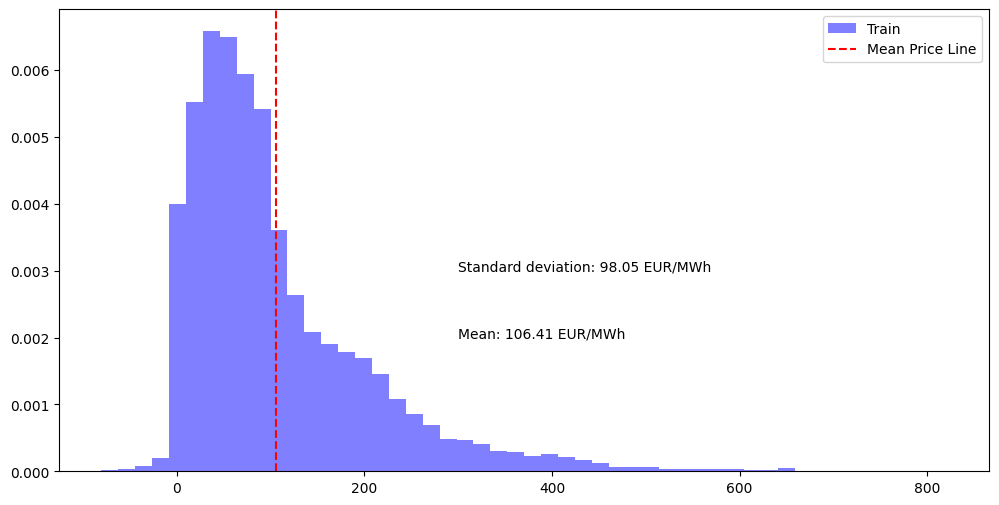

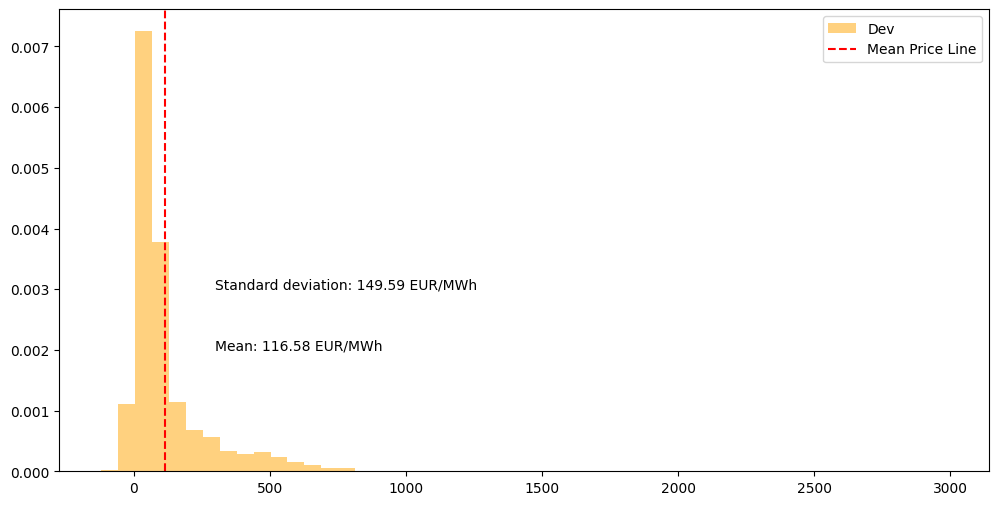

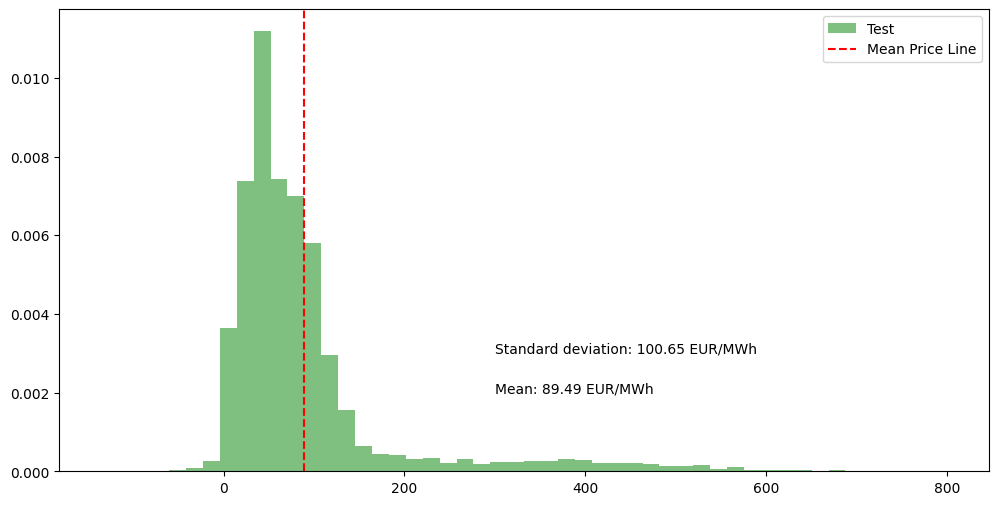

In [20]:
#Plot distribution of train, dev, test sets
plt.figure(figsize=(12,6))
plt.hist(train_df['y'].apply(lambda x: x[0]), bins=50, alpha=0.5, label='Train', color='blue', density=True)
plt.axvline(x=np.mean(train_df['y'].apply(lambda x: x[0])), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.002, "Mean: {:.2f} EUR/MWh".format(np.mean(train_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.text(300, 0.003, "Standard deviation: {:.2f} EUR/MWh".format(np.std(train_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.legend()
plt.show()
plt.figure(figsize=(12,6))
plt.hist(dev_df['y'].apply(lambda x: x[0]), bins=50, alpha=0.5, label='Dev', color='orange', density=True)
plt.axvline(x=np.mean(dev_df['y'].apply(lambda x: x[0])), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.002, "Mean: {:.2f} EUR/MWh".format(np.mean(dev_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.text(300, 0.003, "Standard deviation: {:.2f} EUR/MWh".format(np.std(dev_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.legend()
plt.show()
plt.figure(figsize=(12,6))
plt.hist(test_df['y'].apply(lambda x: x[0]), bins=50, alpha=0.5, label='Test', color='green', density=True)
plt.axvline(x=np.mean(test_df['y'].apply(lambda x: x[0])), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.002, "Mean: {:.2f} EUR/MWh".format(np.mean(test_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.text(300, 0.003, "Standard deviation: {:.2f} EUR/MWh".format(np.std(test_df['y'].apply(lambda x: x[0]))), fontsize=10, color='black')
plt.legend()
plt.show()

In [21]:
#Save train, dev, test sets
train_df.to_pickle(os.path.join("data", "Datasets", "train_set.pkl"))
dev_df.to_pickle(os.path.join("data", "Datasets", "dev_set.pkl"))
test_df.to_pickle(os.path.join("data", "Datasets", "test_set.pkl"))
train_df.to_csv(os.path.join("data", "Datasets","train_set.csv"), index=False)
dev_df.to_csv(os.path.join("data", "Datasets","dev_set.csv"), index=False)
test_df.to_csv(os.path.join("data", "Datasets","test_set.csv"), index=False)